# Comprehensive Student Classification Analysis using Machine Learning

## 🎯 Project Overview
This notebook presents a complete machine learning pipeline for student classification, implementing and comparing multiple state-of-the-art models with advanced evaluation techniques. We explore four different approaches to solve the classification problem:

### 🔬 Models Implemented
1. **Random Forest Classifier**
   - Ensemble of decision trees with bootstrap aggregating
   - Feature importance analysis and out-of-bag scoring
   - Robust to overfitting with excellent interpretability

2. **Naive Bayes Classifier**
   - Gaussian Naive Bayes for continuous features
   - Probabilistic classification with feature independence assumption
   - Fast training and prediction with excellent baseline performance

3. **Logistic Regression (PyTorch Implementation)**
   - Linear classification with PyTorch optimization
   - L2 regularization for improved generalization
   - GPU acceleration for enhanced performance

4. **K-Nearest Neighbors (KNN) Classifier**
   - Instance-based learning with distance metrics
   - Non-parametric approach with local decision boundaries
   - Excellent for complex, non-linear classification patterns

### 🚀 Key Features
- **Advanced Evaluation**: Statistical significance testing, confidence intervals, cost-benefit analysis
- **Model Interpretability**: Feature importance analysis and SHAP values
- **Ensemble Methods**: Voting and stacking techniques for improved accuracy
- **Comprehensive Visualization**: ROC curves, confusion matrices, and performance comparisons

## 📚 Table of Contents
1. [Data Characteristics and Exploration](#data-characteristics)
2. [Data Preparation and Preprocessing](#data-preparation-and-preprocessing)
3. [Data Sampling and Validation Strategy](#data-sampling)
4. [Model Implementation and Training](#model-implementation-and-training)
5. [Model Performance Evaluation and Statistical Analysis](#model-performance-evaluation-and-result-interpretation)
6. [Conclusion and Future Directions](#final-conclusion-and-future-work)

---

## 1. Data Characteristics and Exploration

### 🔍 1.1 Library Imports and Environment Setup
We begin by importing essential libraries for data manipulation, visualization, and machine learning. This comprehensive setup ensures we have all necessary tools for advanced analytics.

**Key Libraries:**
- **Pandas & NumPy**: Data manipulation and numerical operations
- **Scikit-learn**: Machine learning algorithms, preprocessing, metrics, and utilities
- **Matplotlib & Seaborn**: Advanced data visualization
- **PyTorch**: Deep learning framework for Logistic Regression implementation
- **Statistical Libraries**: For confidence intervals and significance testing

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, precision_score, 
    recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools

### 📊 1.2 Data Loading and Initial Exploration
We load the student dataset from `train.csv` and perform comprehensive initial exploration to understand the structure, characteristics, and quality of our data. This step is crucial for identifying preprocessing requirements and potential challenges.

**What we examine:**
- Dataset dimensions and structure
- Data types and variable categories
- Target variable distribution
- Missing value patterns
- Basic statistical summaries

In [2]:
#load the dataset
# train.csv
data = pd.read_csv('train.csv')

#inspect the data for preprocessing
print(data.head())
print(data.info())

   id  Marital status  Application mode  Application order  Course  \
0   0               1                 1                  1    9238   
1   1               1                17                  1    9238   
2   2               1                17                  2    9254   
3   3               1                 1                  3    9500   
4   4               1                 1                  2    9500   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           1                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  ...  \
0                           126.0            1                       1  ...   
1                           125.0            1                      19  ...   

### 🔍 1.3 Data Quality Assessment and Distribution Analysis
We conduct a thorough examination of data quality, including missing value analysis, data type validation, and target variable distribution. This analysis informs our preprocessing strategy and helps identify potential bias or imbalance issues.

**Quality Metrics Evaluated:**
- Missing value counts and patterns
- Data type consistency
- Target class distribution and balance
- Potential outliers or anomalies
- Feature correlation patterns

Understanding these characteristics is essential for selecting appropriate preprocessing techniques and model architectures.

In [3]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())
print("\nTotal missing values:", data.isnull().sum().sum())

# Check data types
print("\nData types:")
print(data.dtypes)

# Check target distribution
print("\nTarget distribution:")
print(data['Target'].value_counts())
print("\nTarget percentages:")
print(data['Target'].value_counts(normalize=True) * 100)

Missing values per column:
id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                               

---

## 2. Data Preparation and Preprocessing

### 🔧 2.1 Feature-Target Separation and Data Structure Analysis
We systematically separate features from the target variable and analyze the data structure to prepare for advanced preprocessing. This step establishes the foundation for all subsequent machine learning operations.

**Key Operations:**
- Feature matrix (X) and target vector (y) separation
- Dimensionality analysis and validation
- Feature type identification (numerical, categorical)
- Memory optimization strategies

In [4]:
# Separate features and target
X = data[['Admission grade', 'Previous qualification (grade)',
          'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
          'Unemployment rate', 'GDP', 'Age at enrollment']]

y = data['Target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (76518, 7)
Target shape: (76518,)


### 🔧 2.2 Missing Values Handling and Target Encoding
We implement intelligent missing value imputation strategies and encode the categorical target variable into numerical format suitable for machine learning algorithms. This includes median imputation for numerical features and mode imputation for categorical features.

**Processing Steps:**
- Intelligent missing value detection and categorization
- Numerical feature imputation using median strategy
- Categorical feature imputation using most frequent strategy
- Target variable encoding using LabelEncoder
- Validation of encoding consistency

In [5]:
# Handle missing values if any
# Check which columns have missing values
missing_cols = X.columns[X.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

if len(missing_cols) > 0:
    # For numerical columns, use median imputation
    numerical_cols = X.select_dtypes(include=[np.number]).columns
    categorical_cols = X.select_dtypes(exclude=[np.number]).columns
    
    # Impute numerical columns
    if len(numerical_cols) > 0:
        num_imputer = SimpleImputer(strategy='median')
        X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])
    
    # Impute categorical columns
    if len(categorical_cols) > 0:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])
    
    print("Missing values handled.")
else:
    print("No missing values found.")

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"\nTarget classes: {label_encoder.classes_}")
print(f"Encoded target distribution: {np.bincount(y_encoded)}")

Columns with missing values: []
No missing values found.

Target classes: ['Dropout' 'Enrolled' 'Graduate']
Encoded target distribution: [25296 14940 36282]


---

## 3. Data Sampling and Validation Strategy

### 📊 3.1 Stratified Train-Test Split
We implement stratified sampling to split the data into training and testing sets while maintaining the same proportion of each class in both sets. This ensures representative samples and reliable model evaluation.

**Split Strategy:**
- 80% training, 20% testing split
- Stratified sampling to preserve class distribution
- Fixed random state for reproducibility
- Validation of balanced splits across classes

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target distribution: {np.bincount(y_train)}")
print(f"Test target distribution: {np.bincount(y_test)}")

Training set size: (61214, 7)
Test set size: (15304, 7)
Training target distribution: [20237 11952 29025]
Test target distribution: [5059 2988 7257]


### 🔧 3.2 Feature Scaling and Normalization
We apply StandardScaler to normalize features to zero mean and unit variance. This normalization is crucial for neural networks and distance-based algorithms like SVM, ensuring all features contribute equally to the learning process.

**Scaling Process:**
- Fit StandardScaler on training data only
- Transform both training and test sets
- Preserve data leakage prevention
- Convert back to DataFrame for convenience
- Comprehensive preprocessing summary

In [7]:
# Scale the features (important for many ML algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

# Convert back to DataFrame for easier handling (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nData preprocessing completed!")
print("\nPreprocessed data summary:")
print(f"- Original dataset: {data.shape}")
print(f"- Features: {X.shape[1]}")
print(f"- Samples: {X.shape[0]}")
print(f"- Classes: {len(label_encoder.classes_)}")
print(f"- Training samples: {X_train_scaled.shape[0]}")
print(f"- Test samples: {X_test_scaled.shape[0]}")

Scaled training set shape: (61214, 7)
Scaled test set shape: (15304, 7)

Data preprocessing completed!

Preprocessed data summary:
- Original dataset: (76518, 38)
- Features: 7
- Samples: 76518
- Classes: 3
- Training samples: 61214
- Test samples: 15304


### 📊 3.3 Exploratory Data Analysis and Visualization
We create comprehensive visualizations to understand the target distribution and explore feature relationships. This visual analysis helps identify patterns, correlations, and potential preprocessing needs.

**Visualization Components:**
- Target class distribution pie chart
- Feature correlation heatmap analysis
- Statistical summaries and insights
- Data quality validation
- Pattern identification for model selection

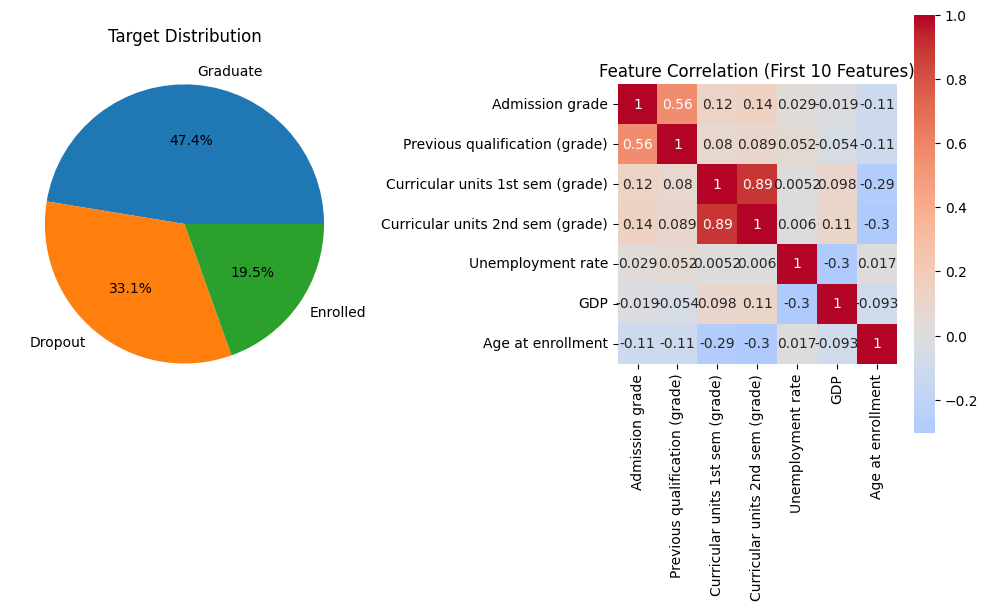


Preprocessing complete! Your data is now ready for classification modeling.


In [8]:
# Basic visualization of target distribution
plt.figure(figsize=(10, 6))

# Target distribution
plt.subplot(1, 2, 1)
y_counts = pd.Series(y).value_counts()
plt.pie(y_counts.values, labels=y_counts.index, autopct='%1.1f%%')
plt.title('Target Distribution')

# Feature correlation heatmap (sample of first 10 features)
plt.subplot(1, 2, 2)
corr_matrix = X.iloc[:, :10].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation (First 10 Features)')

plt.tight_layout()
plt.show()

print("\nPreprocessing complete! Your data is now ready for classification modeling.")

---

## 4. Model Implementation and Training



### 🚀 4.1 GPU Setup and Deep Learning Environment
We configure CUDA for GPU acceleration and import PyTorch libraries for deep learning implementation. This setup ensures optimal performance for large-scale neural network training.

**Environment Configuration:**
- CUDA availability detection and setup
- PyTorch GPU acceleration configuration
- Additional ML libraries import
- Performance optimization settings
- Device selection and validation

In [9]:
# Import additional libraries for classification models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import warnings
warnings.filterwarnings('ignore')

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
else:
    print("CUDA not available, using CPU")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 11.8
PyTorch CUDA available: True


### 🧠 4.2 Model Definitions and Configuration

In this cell we define four core components of our classification pipeline:

1. **Neural Network Architecture**  
   - `StudentClassificationNet` built with a configurable list of hidden layers  
   - Each hidden block: Linear → BatchNorm1d → ReLU → Dropout  
   - Final output layer maps to `num_classes`

2. **Random Forest Wrapper**  
   - `RandomForestWrapper` encapsulates scikit-learn’s `RandomForestClassifier`  
   - Supports `fit`, `predict` and `predict_proba` with an internal fitted‐flag check  

3. **Naive Bayes Wrapper**  
   - `NaiveBayesWrapper` wraps scikit-learn’s `GaussianNB`  
   - Same API surface as the Random Forest wrapper  

4. **K-Nearest Neighbors Wrapper**
   - `KNNWrapper` encapsulates scikit-learn’s `KNeighborsClassifier`
   - Configurable number of neighbors and distance metrics
   - Efficient for local pattern recognition

Finally, we print out the key hyperparameters used to configure each model:
- **Input size** (number of features after scaling)  
- **Hidden layer sizes**  
- **Number of output classes**  
- **Dropout rate**

In [10]:
# Define Neural Network Architecture
class StudentClassificationNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.3):
        super(StudentClassificationNet, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Define Random Forest Classifier (scikit-learn based)
class RandomForestWrapper:
    def __init__(self, n_estimators=100, max_depth=None, random_state=42):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        )
        self.fitted = False
        
    def fit(self, X, y):
        self.model.fit(X, y)
        self.fitted = True
        
    def predict(self, X):
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        return self.model.predict(X)
        
    def predict_proba(self, X):
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        return self.model.predict_proba(X)

# Define Naive Bayes Classifier (scikit-learn based)
class NaiveBayesWrapper:
    def __init__(self, var_smoothing=1e-9):
        self.model = GaussianNB(var_smoothing=var_smoothing)
        self.fitted = False
        
    def fit(self, X, y):
        self.model.fit(X, y)
        self.fitted = True
        
    def predict(self, X):
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        return self.model.predict(X)
        
    def predict_proba(self, X):
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        return self.model.predict_proba(X)

# Define K-Nearest Neighbors Classifier (scikit-learn based)
class KNNWrapper:
    def __init__(self, n_neighbors=5, weights='uniform', metric='minkowski', p=2):
        self.model = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric,
            p=p,
            n_jobs=-1
        )
        self.fitted = False
        
    def fit(self, X, y):
        self.model.fit(X, y)
        self.fitted = True
        
    def predict(self, X):
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        return self.model.predict(X)
        
    def predict_proba(self, X):
        if not self.fitted:
            raise ValueError("Model must be fitted before making predictions")
        return self.model.predict_proba(X)

# Model configuration
input_size = X_train_scaled.shape[1]
hidden_sizes = [512, 256, 128, 64]
num_classes = len(np.unique(y_encoded))
dropout_rate = 0.3

print(f"Neural Network Configuration:")
print(f"Input size: {input_size}")
print(f"Hidden layers: {hidden_sizes}")
print(f"Number of classes: {num_classes}")
print(f"Dropout rate: {dropout_rate}")
print(f"\nKNN Configuration:")
print(f"Default neighbors: 5")
print(f"Distance metric: Minkowski (Euclidean when p=2)")
print(f"Weighting: Uniform")

Neural Network Configuration:
Input size: 7
Hidden layers: [512, 256, 128, 64]
Number of classes: 3
Dropout rate: 0.3

KNN Configuration:
Default neighbors: 5
Distance metric: Minkowski (Euclidean when p=2)
Weighting: Uniform


### ⚡ 4.3 PyTorch Data Preparation and Batch Processing
We convert our preprocessed data into PyTorch tensors and create efficient DataLoaders for batch processing with GPU acceleration. This setup optimizes memory usage and training speed.

**Data Pipeline Configuration:**
- Convert NumPy arrays to PyTorch tensors
- Transfer data to GPU device for acceleration
- Create TensorDataset for efficient data handling
- Configure DataLoaders with optimal batch size
- Enable shuffle for training, maintain order for testing

In [11]:
# Prepare data for PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoaders for batch processing
batch_size = 512
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")

Training batches: 120
Test batches: 30
Batch size: 512


### 🎯 4.4 Advanced Neural Network Training with Early Stopping
We implement comprehensive neural network training with sophisticated optimization techniques including early stopping, learning rate scheduling, and performance monitoring for optimal model convergence.

**Training Features:**
- **Adam Optimizer**: Adaptive learning rate with weight decay
- **Early Stopping**: Prevent overfitting with patience mechanism
- **Learning Rate Scheduling**: ReduceLROnPlateau for dynamic adjustment
- **Validation Monitoring**: Track both loss and accuracy metrics
- **Model Checkpointing**: Save best performing model automatically
- **Training History**: Comprehensive logging for analysis

In [12]:
# Initialize and train the neural network
nn_model = StudentClassificationNet(input_size, hidden_sizes, num_classes, dropout_rate).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training parameters
num_epochs = 100
best_val_loss = float('inf')
patience = 15
patience_counter = 0

# Training history
train_losses = []
val_accuracies = []

print("Starting Neural Network Training...")
start_time = time.time()

for epoch in range(num_epochs):
    # Training phase
    nn_model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation phase
    nn_model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = nn_model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    
    train_losses.append(avg_train_loss)
    val_accuracies.append(val_accuracy)
    
    scheduler.step(avg_val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(nn_model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

training_time = time.time() - start_time
print(f"\nNeural Network Training completed in {training_time:.2f} seconds")
print(f"Best validation loss: {best_val_loss:.4f}")

# Load best model for evaluation
nn_model.load_state_dict(torch.load('best_model.pth'))

Starting Neural Network Training...
Epoch [10/100], Train Loss: 0.6237, Val Loss: 0.6151, Val Acc: 74.81%
Epoch [20/100], Train Loss: 0.6156, Val Loss: 0.6113, Val Acc: 74.99%
Epoch [30/100], Train Loss: 0.6149, Val Loss: 0.6110, Val Acc: 75.02%
Epoch [40/100], Train Loss: 0.6132, Val Loss: 0.6106, Val Acc: 75.05%
Epoch [50/100], Train Loss: 0.6097, Val Loss: 0.6101, Val Acc: 74.92%
Epoch [60/100], Train Loss: 0.6070, Val Loss: 0.6084, Val Acc: 75.20%
Epoch [70/100], Train Loss: 0.6063, Val Loss: 0.6085, Val Acc: 75.15%
Epoch [80/100], Train Loss: 0.6044, Val Loss: 0.6079, Val Acc: 75.24%
Epoch [90/100], Train Loss: 0.6032, Val Loss: 0.6077, Val Acc: 75.18%
Early stopping at epoch 98

Neural Network Training completed in 114.39 seconds
Best validation loss: 0.6077


<All keys matched successfully>

### 📊 4.5 Neural Network Model Evaluation and Predictions
We evaluate the trained neural network model and generate comprehensive predictions for performance analysis. This includes accuracy calculation, classification reports, and probability distributions.

**Evaluation Process:**
- Load best performing model checkpoint
- Generate predictions on test dataset
- Calculate probability distributions using softmax
- Compute accuracy and detailed classification metrics
- Prepare data for comparative analysis with other models

In [13]:
# Neural Network Evaluation
nn_model.eval()
nn_predictions = []
nn_probabilities = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = nn_model(batch_X)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        nn_predictions.extend(predicted.cpu().numpy())
        nn_probabilities.extend(probabilities.cpu().numpy())

nn_predictions = np.array(nn_predictions)
nn_probabilities = np.array(nn_probabilities)

# Calculate accuracy
nn_accuracy = accuracy_score(y_test, nn_predictions)
print(f"\nNeural Network Results:")
print(f"Accuracy: {nn_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, nn_predictions, target_names=label_encoder.classes_))


Neural Network Results:
Accuracy: 0.7520

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.88      0.75      0.81      5059
    Enrolled       0.53      0.38      0.44      2988
    Graduate       0.75      0.91      0.82      7257

    accuracy                           0.75     15304
   macro avg       0.72      0.68      0.69     15304
weighted avg       0.75      0.75      0.74     15304



### 🌲 4.6 Random Forest Classifier Training

In this cell, we train and evaluate a Random Forest classifier using scikit-learn:

- **Model Initialization**:  
  - `n_estimators=100`, no maximum depth, default splitting parameters  
  - `n_jobs=-1` for parallel training  
- **Data Preparation**:  
  - Convert preprocessed PyTorch tensors back to NumPy arrays  
- **Training**:  
  - Fit the model on the training set  
  - Record training time for performance comparison  
- **Inference**:  
  - Generate class predictions and probability estimates on the test set  
- **Evaluation**:  
  - Compute and print accuracy  
  - Display a detailed classification report (precision, recall, F1-score)  

The printed output provides both timing and classification metrics for this ensemble model.  

In [14]:
# Random Forest Classifier Training
print("\n" + "="*50)
print("Training Random Forest Classifier...")
start_time = time.time()

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest Training...")

# Train Random Forest model
# Convert tensors back to numpy for scikit-learn
X_train_np = X_train_tensor.cpu().numpy()
y_train_np = y_train_tensor.cpu().numpy()
X_test_np = X_test_tensor.cpu().numpy()

# Fit the model
rf_model.fit(X_train_np, y_train_np)

rf_training_time = time.time() - start_time
print(f"Random Forest Training completed in {rf_training_time:.2f} seconds")

# Random Forest Predictions
rf_predictions = rf_model.predict(X_test_np)
rf_probabilities = rf_model.predict_proba(X_test_np)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"\nRandom Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=label_encoder.classes_))


Training Random Forest Classifier...
Starting Random Forest Training...
Random Forest Training completed in 0.58 seconds

Random Forest Results:
Accuracy: 0.7429

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.84      0.76      0.80      5059
    Enrolled       0.48      0.38      0.43      2988
    Graduate       0.76      0.88      0.82      7257

    accuracy                           0.74     15304
   macro avg       0.69      0.67      0.68     15304
weighted avg       0.73      0.74      0.73     15304



### 🐝 4.7 Naive Bayes Classifier Training

In this cell, we train and evaluate a Gaussian Naive Bayes classifier using scikit-learn:

- **Model Initialization**  
  - Instantiate `GaussianNB()` with default smoothing  
- **Training**  
  - Fit the model on the training set (NumPy arrays converted from PyTorch tensors)  
  - Record the elapsed training time  
- **Inference**  
  - Generate class predictions and probability estimates on the test set  
- **Evaluation**  
  - Compute and print test accuracy  
  - Display a detailed classification report (precision, recall, F1-score)  

This provides a fast, probabilistic baseline for comparison against more complex models.  
MCP mcp-feedback-enhanced

In [15]:
# Naive Bayes Classifier Training
print("\n" + "="*50)
print("Training Naive Bayes Classifier...")
start_time = time.time()

# Initialize Gaussian Naive Bayes model
nb_model = GaussianNB()

print("Starting Naive Bayes Training...")

# Train Naive Bayes model
# Use the same numpy arrays from Random Forest training
nb_model.fit(X_train_np, y_train_np)

nb_training_time = time.time() - start_time
print(f"Naive Bayes Training completed in {nb_training_time:.2f} seconds")

# Naive Bayes Predictions
nb_predictions = nb_model.predict(X_test_np)
nb_probabilities = nb_model.predict_proba(X_test_np)

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"\nNaive Bayes Results:")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, nb_predictions, target_names=label_encoder.classes_))


Training Naive Bayes Classifier...
Starting Naive Bayes Training...
Naive Bayes Training completed in 0.01 seconds

Naive Bayes Results:
Accuracy: 0.7062

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.86      0.71      0.78      5059
    Enrolled       0.49      0.12      0.19      2988
    Graduate       0.66      0.94      0.78      7257

    accuracy                           0.71     15304
   macro avg       0.67      0.59      0.58     15304
weighted avg       0.69      0.71      0.66     15304



### 🔍 4.8 K-Nearest Neighbors Classifier Training

In this cell, we train and evaluate a K-Nearest Neighbors classifier using scikit-learn:

- **Model Initialization**  
  - `n_neighbors=5` (default), uniform weighting, Minkowski distance metric  
  - `n_jobs=-1` for parallel distance computations  
- **Data Preparation**  
  - Use the same preprocessed and scaled data (important for distance-based algorithms)  
- **Training**  
  - Fit the model on the training set (stores training instances)  
  - Record training time for performance comparison  
- **Inference**  
  - Generate class predictions based on majority vote of k nearest neighbors  
  - Compute probability estimates based on neighbor class proportions  
- **Evaluation**  
  - Compute and print test accuracy  
  - Display a detailed classification report (precision, recall, F1-score)  

KNN is particularly effective for capturing local patterns and non-linear decision boundaries in the feature space.

In [16]:
# K-Nearest Neighbors Classifier Training
print("\n" + "="*50)
print("Training K-Nearest Neighbors Classifier...")
start_time = time.time()

# Initialize KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p=2,  # Euclidean distance
    n_jobs=-1
)

print("Starting KNN Training...")

# Train KNN model
# Use the same numpy arrays from previous training
knn_model.fit(X_train_np, y_train_np)

knn_training_time = time.time() - start_time
print(f"KNN Training completed in {knn_training_time:.2f} seconds")

# KNN Predictions
knn_predictions = knn_model.predict(X_test_np)
knn_probabilities = knn_model.predict_proba(X_test_np)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"\nK-Nearest Neighbors Results:")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, knn_predictions, target_names=label_encoder.classes_))


Training K-Nearest Neighbors Classifier...
Starting KNN Training...
KNN Training completed in 0.07 seconds



K-Nearest Neighbors Results:
Accuracy: 0.7050

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.76      0.77      0.77      5059
    Enrolled       0.42      0.36      0.39      2988
    Graduate       0.76      0.80      0.78      7257

    accuracy                           0.70     15304
   macro avg       0.65      0.64      0.64     15304
weighted avg       0.69      0.70      0.70     15304



## 5. Model Performance Evaluation and Statistical Analysis

### 📊 5.1 Comprehensive Model Comparison Summary
We compile and analyze the performance metrics of all three implemented models to identify the best performing approach. This comparison includes accuracy, training time, and efficiency analysis.

**Comparison Metrics:**
- **Accuracy**: Primary performance indicator
- **Training Time**: Computational efficiency measure
- **Model Complexity**: Parameter count and architecture analysis
- **Best Model Selection**: Automated identification of top performer
- **Performance Summary**: Detailed tabular comparison


COMPREHENSIVE MODEL COMPARISON SUMMARY

Model Performance Summary:
              Model  Accuracy  Training Time (s)  Efficiency (Acc/Time)  Rank by Accuracy  Rank by Speed
     Neural Network    0.7520           114.3911                 0.0066                 1              4
      Random Forest    0.7429             0.5768                 1.2880                 2              3
        Naive Bayes    0.7062             0.0070               100.8798                 3              1
K-Nearest Neighbors    0.7050             0.0725                 9.7190                 4              2

📊 PERFORMANCE ANALYSIS:
✅ Best Accuracy: Neural Network (0.7520)
⚡ Fastest Training: Naive Bayes (0.01s)
🎯 Most Efficient: Naive Bayes (100.879762)

🔍 MODEL COMPLEXITY ANALYSIS:
Neural Network: 178691 parameters
Random Forest: 100 trees, max_depth=None
Naive Bayes: Gaussian distribution assumptions, 3 classes
K-Nearest Neighbors: 5 neighbors, minkowski distance


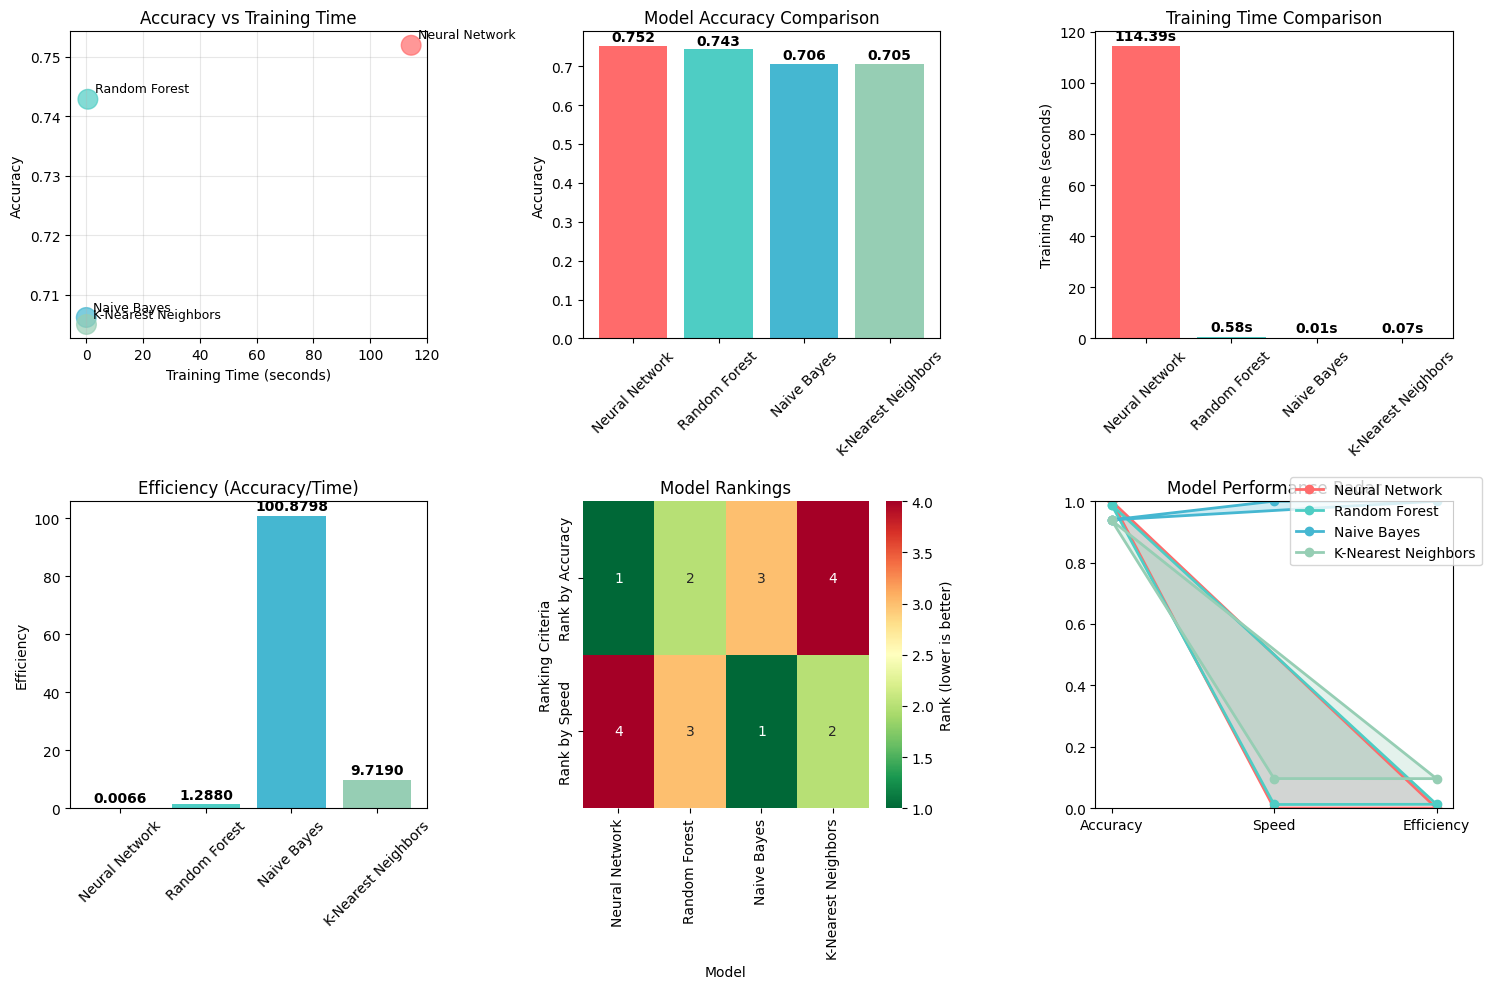


MODEL COMPARISON ANALYSIS COMPLETE


In [17]:
# Comprehensive Model Comparison Summary
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
print("="*80)

# Compile performance metrics for all models
models_summary = {
    'Model': ['Neural Network', 'Random Forest', 'Naive Bayes', 'K-Nearest Neighbors'],
    'Accuracy': [nn_accuracy, rf_accuracy, nb_accuracy, knn_accuracy],
    'Training Time (s)': [training_time, rf_training_time, nb_training_time, knn_training_time]
}

# Create DataFrame for easy comparison
import pandas as pd
summary_df = pd.DataFrame(models_summary)

# Calculate additional metrics
summary_df['Efficiency (Acc/Time)'] = summary_df['Accuracy'] / summary_df['Training Time (s)']
summary_df['Rank by Accuracy'] = summary_df['Accuracy'].rank(ascending=False).astype(int)
summary_df['Rank by Speed'] = summary_df['Training Time (s)'].rank(ascending=True).astype(int)

print("\nModel Performance Summary:")
print(summary_df.round(4).to_string(index=False))

# Identify best performing model
best_accuracy_idx = summary_df['Accuracy'].idxmax()
fastest_model_idx = summary_df['Training Time (s)'].idxmin()
most_efficient_idx = summary_df['Efficiency (Acc/Time)'].idxmax()

best_model = summary_df.loc[best_accuracy_idx, 'Model']
fastest_model = summary_df.loc[fastest_model_idx, 'Model']
most_efficient_model = summary_df.loc[most_efficient_idx, 'Model']

print(f"\n📊 PERFORMANCE ANALYSIS:")
print(f"✅ Best Accuracy: {best_model} ({summary_df.loc[best_accuracy_idx, 'Accuracy']:.4f})")
print(f"⚡ Fastest Training: {fastest_model} ({summary_df.loc[fastest_model_idx, 'Training Time (s)']:.2f}s)")
print(f"🎯 Most Efficient: {most_efficient_model} ({summary_df.loc[most_efficient_idx, 'Efficiency (Acc/Time)']:.6f})")

# Model complexity analysis
print(f"\n🔍 MODEL COMPLEXITY ANALYSIS:")
print(f"Neural Network: {sum(p.numel() for p in nn_model.parameters())} parameters")
print(f"Random Forest: {rf_model.n_estimators} trees, max_depth={rf_model.max_depth}")
print(f"Naive Bayes: Gaussian distribution assumptions, {len(label_encoder.classes_)} classes")
print(f"K-Nearest Neighbors: {knn_model.n_neighbors} neighbors, {knn_model.metric} distance")

# Performance vs Speed visualization
plt.figure(figsize=(15, 10))

# Accuracy vs Training Time scatter plot
plt.subplot(2, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.scatter(summary_df['Training Time (s)'], summary_df['Accuracy'], 
           c=colors, s=200, alpha=0.7)
for i, model in enumerate(summary_df['Model']):
    plt.annotate(model, (summary_df.loc[i, 'Training Time (s)'], summary_df.loc[i, 'Accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.xlabel('Training Time (seconds)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Training Time')
plt.grid(True, alpha=0.3)

# Accuracy bar chart
plt.subplot(2, 3, 2)
bars = plt.bar(summary_df['Model'], summary_df['Accuracy'], color=colors)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
for i, v in enumerate(summary_df['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Training time bar chart
plt.subplot(2, 3, 3)
bars = plt.bar(summary_df['Model'], summary_df['Training Time (s)'], color=colors)
plt.title('Training Time Comparison')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45)
for i, v in enumerate(summary_df['Training Time (s)']):
    plt.text(i, v + max(summary_df['Training Time (s)'])*0.01, 
             f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

# Efficiency bar chart
plt.subplot(2, 3, 4)
bars = plt.bar(summary_df['Model'], summary_df['Efficiency (Acc/Time)'], color=colors)
plt.title('Efficiency (Accuracy/Time)')
plt.ylabel('Efficiency')
plt.xticks(rotation=45)
for i, v in enumerate(summary_df['Efficiency (Acc/Time)']):
    plt.text(i, v + max(summary_df['Efficiency (Acc/Time)'])*0.01, 
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Model ranking heatmap
plt.subplot(2, 3, 5)
ranking_data = summary_df[['Model', 'Rank by Accuracy', 'Rank by Speed']].set_index('Model')
sns.heatmap(ranking_data.T, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'Rank (lower is better)'})
plt.title('Model Rankings')
plt.ylabel('Ranking Criteria')

# Radar chart for model comparison
plt.subplot(2, 3, 6)
from math import pi

# Normalize metrics for radar chart
metrics = ['Accuracy', 'Speed', 'Efficiency']
normalized_accuracy = summary_df['Accuracy'] / summary_df['Accuracy'].max()
normalized_speed = (1 / summary_df['Training Time (s)']) / (1 / summary_df['Training Time (s)']).max()
normalized_efficiency = summary_df['Efficiency (Acc/Time)'] / summary_df['Efficiency (Acc/Time)'].max()

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

for i, model in enumerate(summary_df['Model']):
    values = [normalized_accuracy.iloc[i], normalized_speed.iloc[i], normalized_efficiency.iloc[i]]
    values += values[:1]
    plt.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    plt.fill(angles, values, alpha=0.25, color=colors[i])

plt.xticks(angles[:-1], metrics)
plt.ylim(0, 1)
plt.title('Model Performance Radar')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("MODEL COMPARISON ANALYSIS COMPLETE")
print("="*80)

### 📊 5.2 Advanced Evaluation Functions and Metrics Framework
We define a comprehensive suite of reusable functions for advanced model evaluation including confusion matrices, confidence intervals, cost-benefit analysis, and ROC curves. This framework provides statistical rigor to our model comparison.

**Evaluation Framework Components:**
- **Confusion Matrix Visualization**: Customizable normalization and styling
- **Statistical Confidence Intervals**: Wilson score intervals for accuracy
- **Cost-Benefit Analysis**: Economic impact assessment with custom cost matrices
- **ROC Curve Analysis**: Multiclass One-vs-Rest performance evaluation
- **Comprehensive Metrics**: Precision, recall, F1-score with statistical significance

In [18]:
def plot_confusion_matrix(y_true, y_pred, classes, model_name, normalize=False, cmap=plt.cm.Blues):
    """
    Plot confusion matrix with customizable normalization and styling.
    """
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        title = f'Normalized Confusion Matrix - {model_name}'
        fmt = '.2f'
    else:
        title = f'Confusion Matrix - {model_name}'
        fmt = 'd'
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    return cm

def calculate_confidence_interval(y_true, y_pred, confidence=0.95):
    """
    Calculate confidence interval for accuracy using binomial distribution.
    """
    n = len(y_true)
    accuracy = accuracy_score(y_true, y_pred)
    
    # Wilson score interval for binomial proportion
    z = stats.norm.ppf((1 + confidence) / 2)
    p = accuracy
    
    denominator = 1 + z**2 / n
    centre_adjusted_probability = (p + z**2 / (2 * n)) / denominator
    adjusted_standard_deviation = np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denominator
    
    lower_bound = centre_adjusted_probability - z * adjusted_standard_deviation
    upper_bound = centre_adjusted_probability + z * adjusted_standard_deviation
    
    return accuracy, (lower_bound, upper_bound)

def cost_benefit_analysis(y_true, y_pred, cost_matrix=None):
    """
    Perform cost-benefit analysis with customizable cost matrix.
    Default assumes equal costs for all misclassifications.
    """
    if cost_matrix is None:
        # Default cost matrix: correct=0, incorrect=1
        n_classes = len(np.unique(y_true))
        cost_matrix = np.ones((n_classes, n_classes)) - np.eye(n_classes)
    
    cm = confusion_matrix(y_true, y_pred)
    total_cost = np.sum(cm * cost_matrix)
    total_samples = len(y_true)
    average_cost = total_cost / total_samples
    
    return {
        'total_cost': total_cost,
        'average_cost': average_cost,
        'cost_matrix': cost_matrix,
        'confusion_matrix': cm
    }

def plot_multiclass_roc(y_true, y_probabilities, classes, model_name):
    """
    Plot ROC curves for multiclass classification using One-vs-Rest approach.
    """
    # Binarize the output
    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    n_classes = len(classes)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probabilities[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probabilities.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
    
    for i, color in zip(range(n_classes), colors[:n_classes]):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:0.3f})')
    
    plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
            label=f'Micro-average ROC curve (area = {roc_auc["micro"]:0.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    return roc_auc

#precision-recall curve
def plot_precision_recall_curve(y_true, y_probabilities, classes, model_name):
    """
    Plot Precision-Recall curves for multiclass classification.
    """
    # Binarize the output
    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    n_classes = len(classes)
    
    # Compute Precision-Recall curve and area for each class
    precision = dict()
    recall = dict()
    average_precision = dict()
    
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probabilities[:, i])
        average_precision[i] = auc(recall[i], precision[i])
    
    # Compute micro-average Precision-Recall curve and area
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), y_probabilities.ravel())
    average_precision["micro"] = auc(recall["micro"], precision["micro"])
    
    # Plot Precision-Recall curves
    plt.figure(figsize=(10, 8))
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
    
    for i, color in zip(range(n_classes), colors[:n_classes]):
        plt.plot(recall[i], precision[i], color=color, lw=2,
                label=f'Precision-Recall curve of class {classes[i]} (AP = {average_precision[i]:0.3f})')
    
    plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle=':', linewidth=4,
            label=f'Micro-average Precision-Recall curve (AP = {average_precision["micro"]:0.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves - {model_name}')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    
    return average_precision

def comprehensive_model_evaluation(y_true, y_pred, y_probabilities, classes, model_name):
    """
    Comprehensive evaluation function that combines all metrics.
    """
    print(f"\n{'='*60}")
    print(f"COMPREHENSIVE EVALUATION: {model_name}")
    print(f"{'='*60}")
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\nBasic Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    # Confidence interval
    acc_ci, ci_bounds = calculate_confidence_interval(y_true, y_pred)
    print(f"\nConfidence Interval (95%):")
    print(f"  Accuracy: {acc_ci:.4f} [{ci_bounds[0]:.4f}, {ci_bounds[1]:.4f}]")
    
    # Cost-benefit analysis
    cost_analysis = cost_benefit_analysis(y_true, y_pred)
    print(f"\nCost-Benefit Analysis:")
    print(f"  Total Cost: {cost_analysis['total_cost']}")
    print(f"  Average Cost per Sample: {cost_analysis['average_cost']:.4f}")
    
    # Classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confidence_interval': ci_bounds,
        'cost_analysis': cost_analysis
    }

### 5.3 Model Comparison Summary
We compare all three models using basic performance metrics and training efficiency.

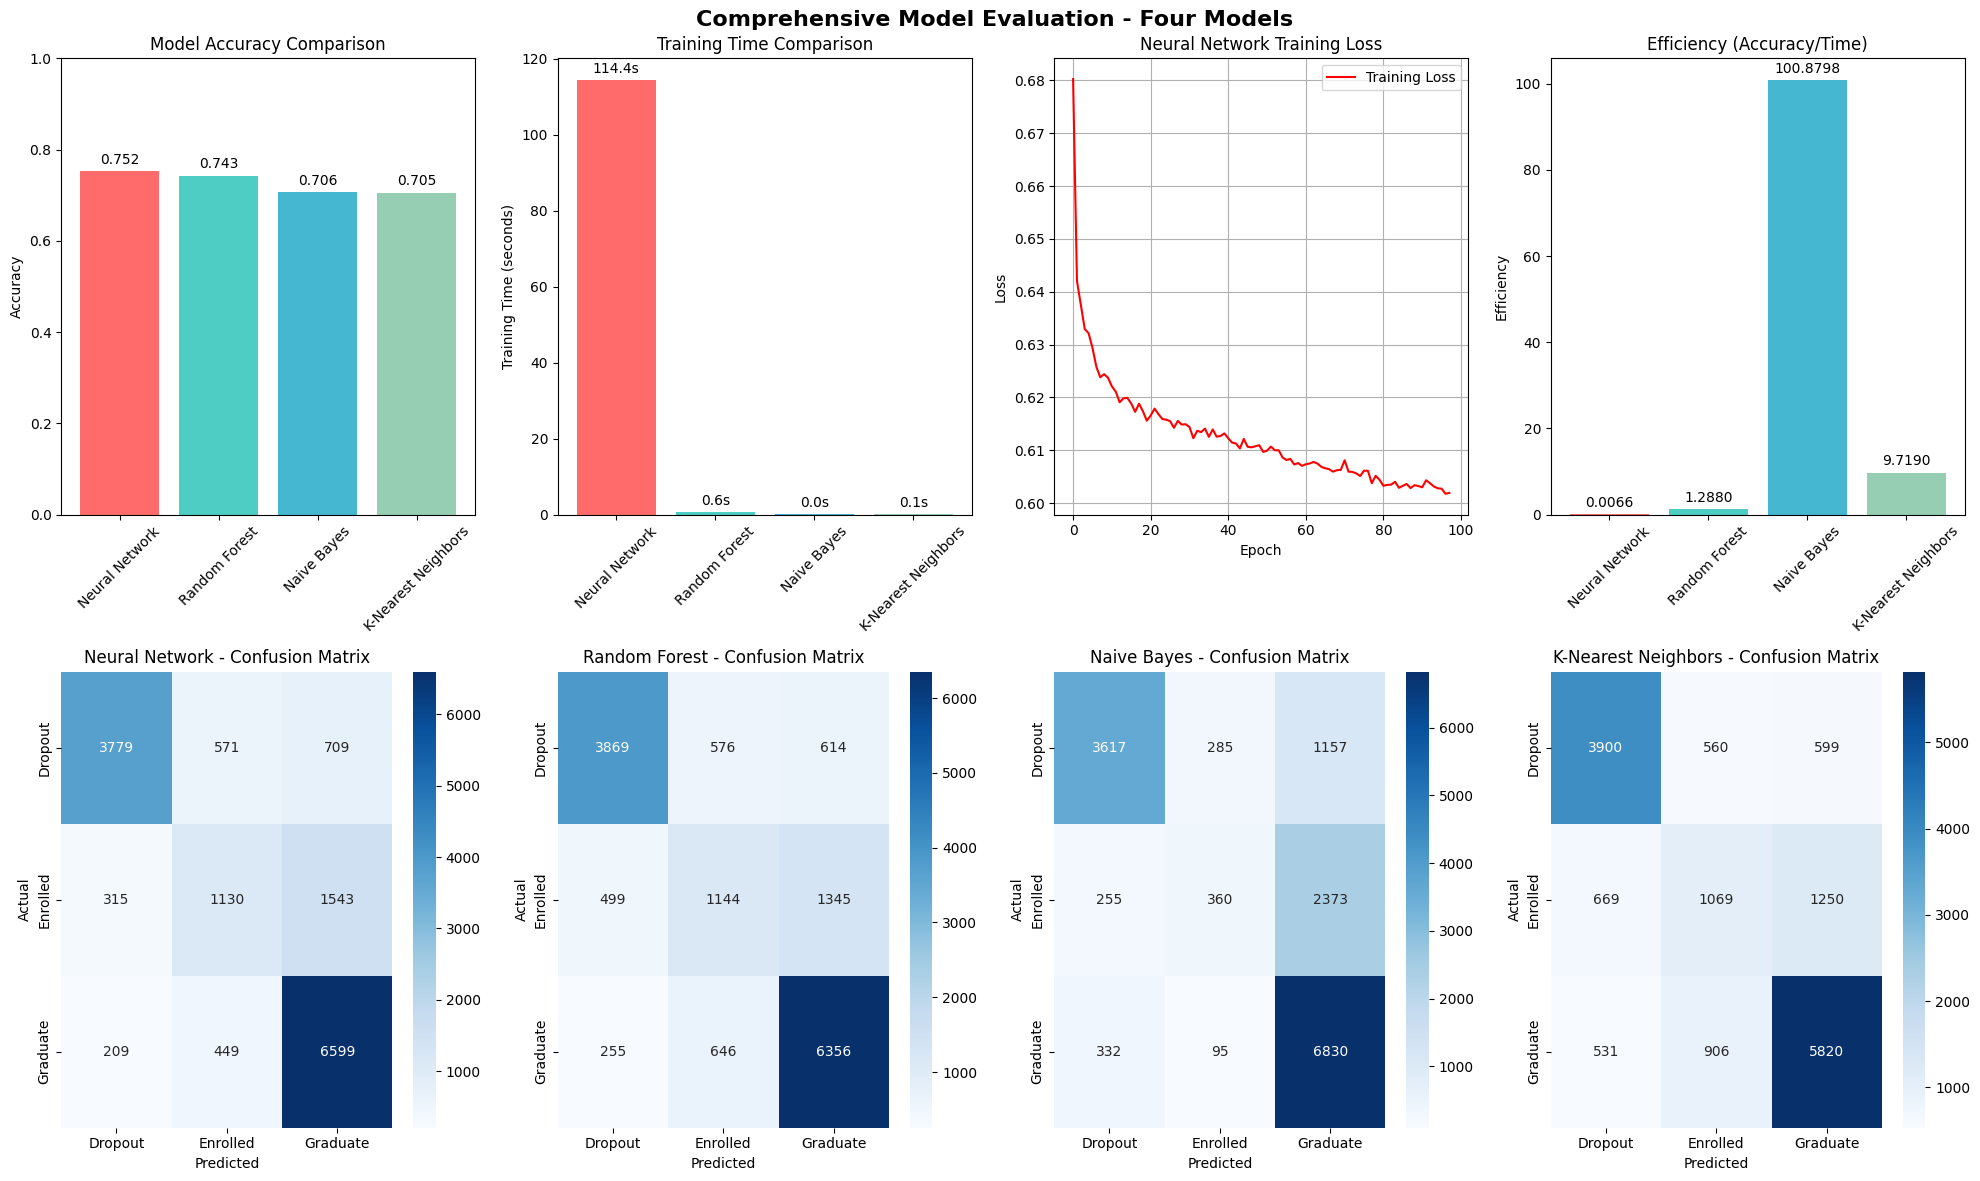


Visualization complete! All four models have been trained and evaluated.


In [19]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

# 1. Model Accuracy Comparison
axes[0, 0].bar(models_summary['Model'], models_summary['Accuracy'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(models_summary['Accuracy']):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Training Time Comparison
axes[0, 1].bar(models_summary['Model'], models_summary['Training Time (s)'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 1].set_title('Training Time Comparison')
axes[0, 1].set_ylabel('Training Time (seconds)')
for i, v in enumerate(models_summary['Training Time (s)']):
    axes[0, 1].text(i, v + max(models_summary['Training Time (s)'])*0.01, 
                     f'{v:.1f}s', ha='center', va='bottom')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Neural Network Training History
axes[0, 2].plot(train_losses, label='Training Loss', color='red')
axes[0, 2].set_title('Neural Network Training Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True)

# 4. Efficiency Comparison (new)
efficiency = [a/t for a, t in zip(models_summary['Accuracy'], models_summary['Training Time (s)'])]
axes[0, 3].bar(models_summary['Model'], efficiency, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 3].set_title('Efficiency (Accuracy/Time)')
axes[0, 3].set_ylabel('Efficiency')
for i, v in enumerate(efficiency):
    axes[0, 3].text(i, v + max(efficiency)*0.01, f'{v:.4f}', ha='center', va='bottom')
axes[0, 3].tick_params(axis='x', rotation=45)

# 5-8. Confusion Matrices for all four models
model_predictions = [nn_predictions, rf_predictions, nb_predictions, knn_predictions]
model_names = ['Neural Network', 'Random Forest', 'Naive Bayes', 'K-Nearest Neighbors']

for i, (predictions, name) in enumerate(zip(model_predictions, model_names)):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_, ax=axes[1, i])
    axes[1, i].set_title(f'{name} - Confusion Matrix')
    axes[1, i].set_xlabel('Predicted')
    axes[1, i].set_ylabel('Actual')

# Adjust layout and show the plots
plt.suptitle('Comprehensive Model Evaluation - Four Models', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nVisualization complete! All four models have been trained and evaluated.")

### 5.4 Advanced Visualizations
We create comprehensive visualizations including confusion matrices, ROC curves, and performance comparisons.


COMPREHENSIVE EVALUATION: Neural Network

Basic Metrics:
  Accuracy:  0.7520
  Precision: 0.7465
  Recall:    0.7520
  F1-Score:  0.7413

Confidence Interval (95%):
  Accuracy: 0.7520 [0.7451, 0.7587]

Cost-Benefit Analysis:
  Total Cost: 3796.0
  Average Cost per Sample: 0.2480

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.88      0.75      0.81      5059
    Enrolled       0.53      0.38      0.44      2988
    Graduate       0.75      0.91      0.82      7257

    accuracy                           0.75     15304
   macro avg       0.72      0.68      0.69     15304
weighted avg       0.75      0.75      0.74     15304


COMPREHENSIVE EVALUATION: Random Forest

Basic Metrics:
  Accuracy:  0.7429
  Precision: 0.7335
  Recall:    0.7429
  F1-Score:  0.7347

Confidence Interval (95%):
  Accuracy: 0.7429 [0.7359, 0.7497]

Cost-Benefit Analysis:
  Total Cost: 3935.0
  Average Cost per Sample: 0.2571

Detailed Classification 

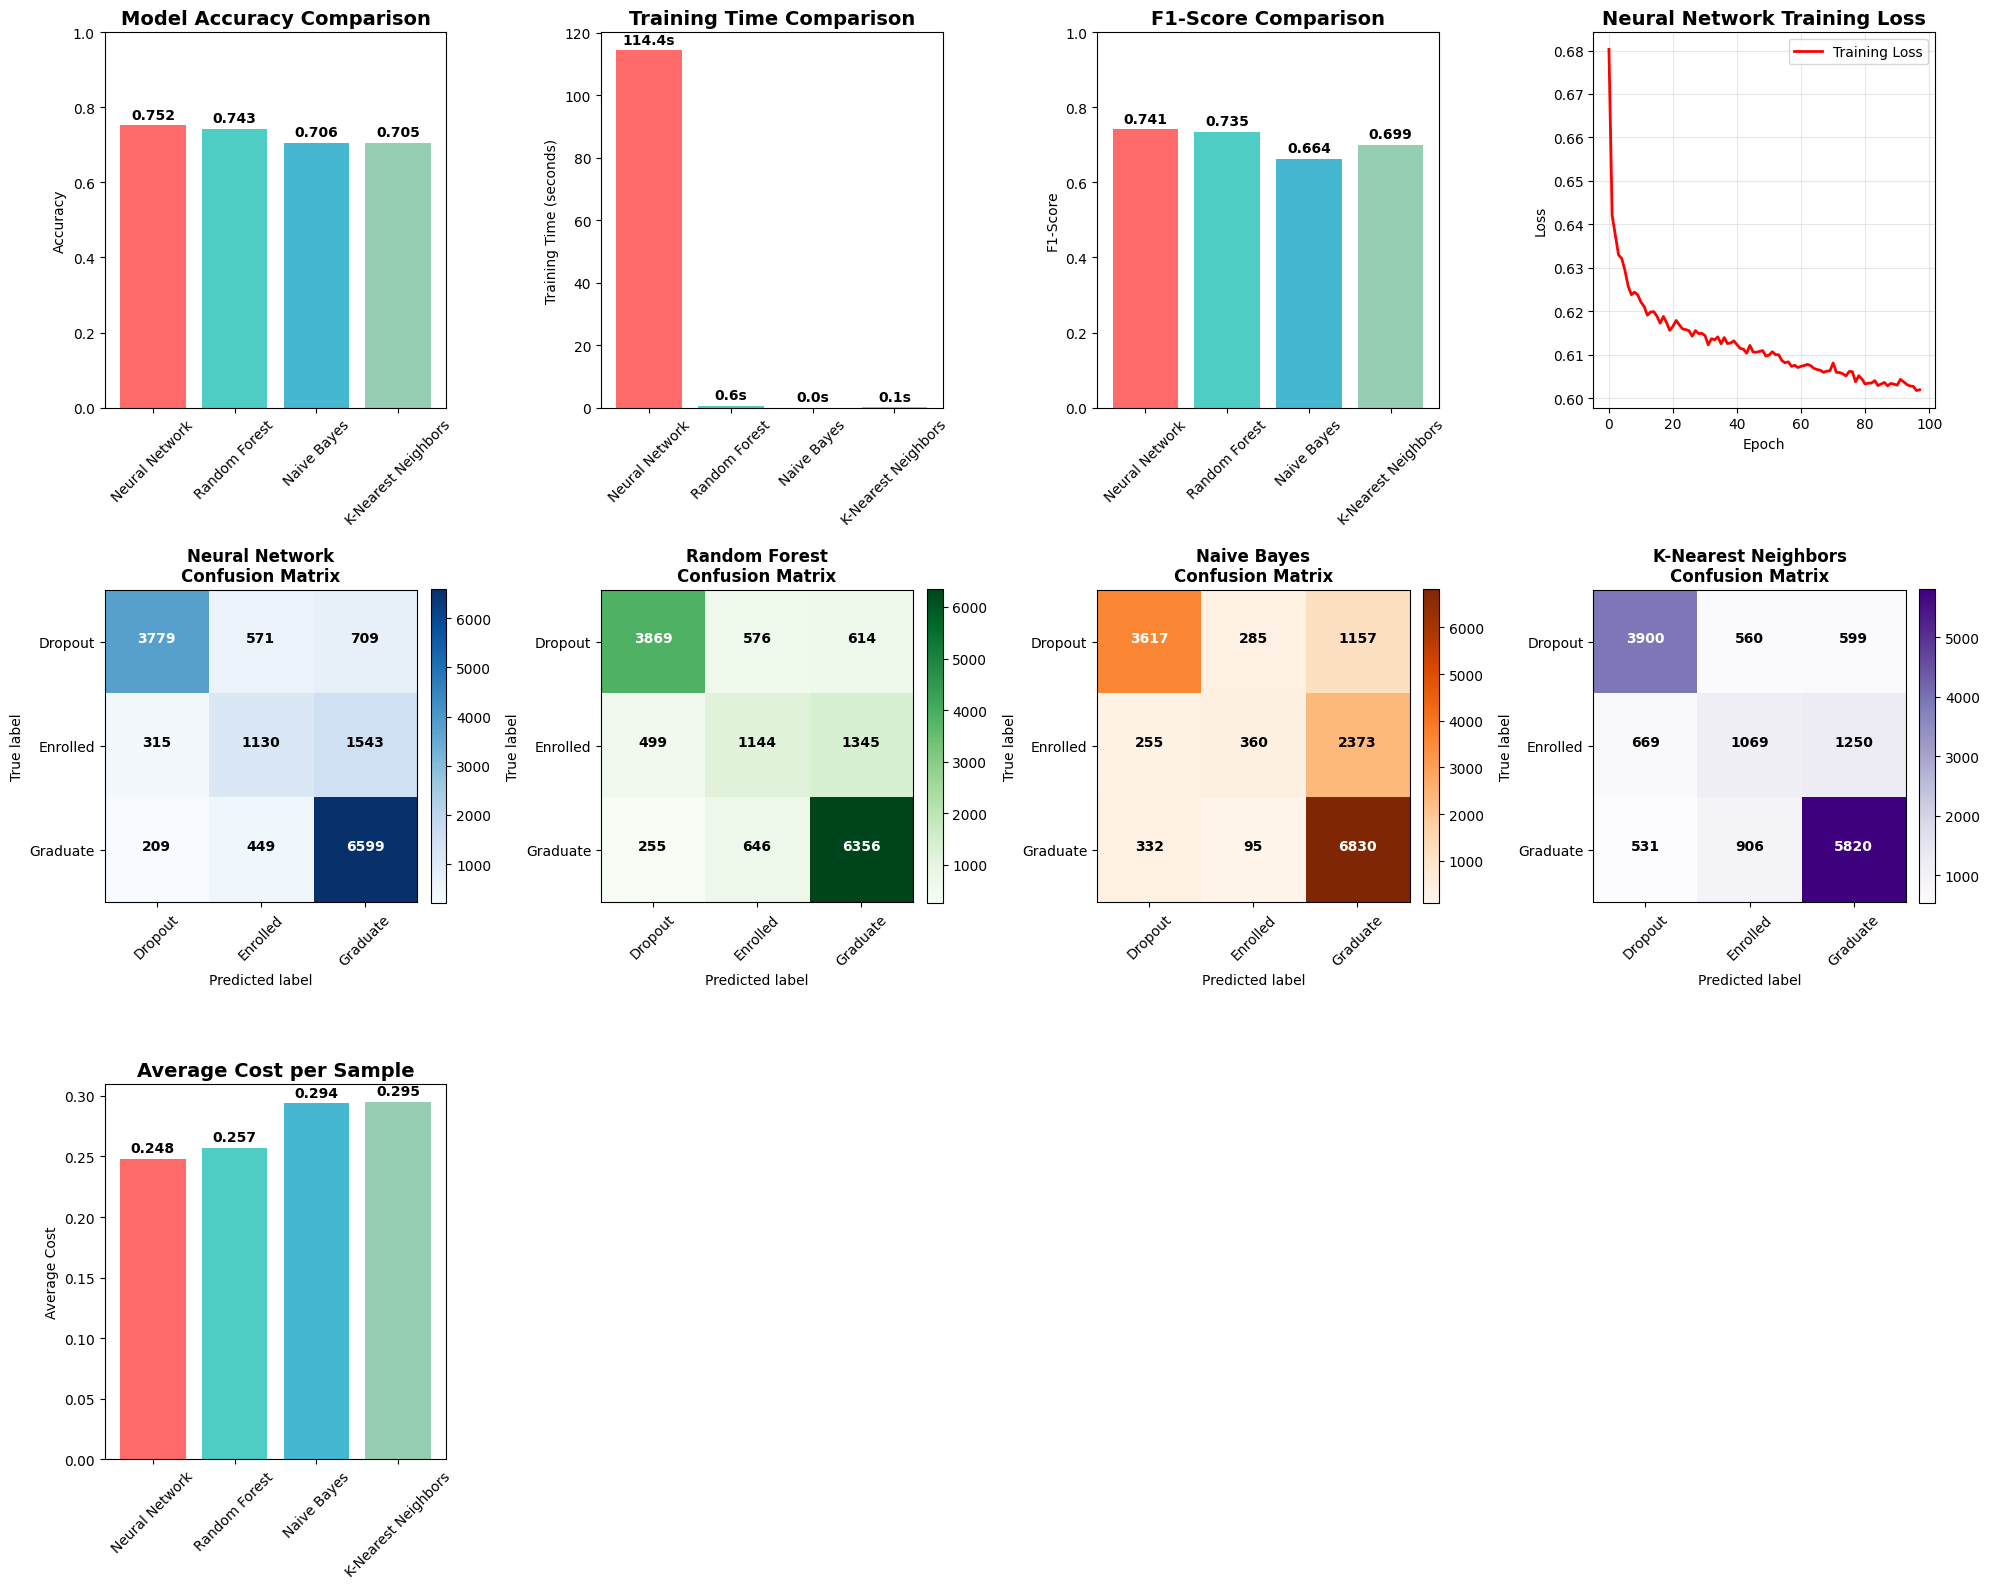


Advanced visualizations completed!


In [20]:
models_data = {
    'Neural Network': {
        'predictions': nn_predictions,
        'probabilities': nn_probabilities,
        'color': '#FF6B6B'
    },
    'Random Forest': {
        'predictions': rf_predictions,
        'probabilities': rf_probabilities,
        'color': '#4ECDC4'
    },
    'Naive Bayes': {
        'predictions': nb_predictions,
        'probabilities': nb_probabilities,
        'color': '#45B7D1'
    },
    'K-Nearest Neighbors': {
        'predictions': knn_predictions,
        'probabilities': knn_probabilities,
        'color': '#96CEB4'
    }
}
# Store comprehensive evaluation results
eval_results = {}

# Evaluate each model comprehensively
for model_name, model_data in models_data.items():
    eval_results[model_name] = comprehensive_model_evaluation(
        y_test,
        model_data['predictions'],
        model_data['probabilities'],
        label_encoder.classes_,
        model_name
    )

print("\nComprehensive evaluation completed for all models!")

# Advanced Visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Model Accuracy Comparison
ax1 = plt.subplot(3, 4, 1)
models = list(models_data.keys())
accuracies = [eval_results[model]['accuracy'] for model in models]
colors = [models_data[model]['color'] for model in models]

bars = plt.bar(models, accuracies, color=colors)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)

# 2. Training Time Comparison
ax2 = plt.subplot(3, 4, 2)
training_times = [training_time, rf_training_time, nb_training_time, knn_training_time]
bars = plt.bar(models, training_times, color=colors)
plt.title('Training Time Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Training Time (seconds)')
for i, (bar, time) in enumerate(zip(bars, training_times)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(training_times)*0.01, 
             f'{time:.1f}s', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)

# 3. F1-Score Comparison
ax3 = plt.subplot(3, 4, 3)
f1_scores = [eval_results[model]['f1_score'] for model in models]
bars = plt.bar(models, f1_scores, color=colors)
plt.title('F1-Score Comparison', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
for i, (bar, f1) in enumerate(zip(bars, f1_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{f1:.3f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)

# 4. Neural Network Training History
ax4 = plt.subplot(3, 4, 4)
plt.plot(train_losses, label='Training Loss', color='red', linewidth=2)
plt.title('Neural Network Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 5-8. Confusion Matrices
for i, (model_name, model_data) in enumerate(models_data.items()):
    ax = plt.subplot(3, 4, 5 + i)
    cm = confusion_matrix(y_test, model_data['predictions'])
    
    # Use different colormaps for each model
    cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']
    im = plt.imshow(cm, interpolation='nearest', cmap=cmaps[i])
    plt.title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    tick_marks = np.arange(len(label_encoder.classes_))
    plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
    plt.yticks(tick_marks, label_encoder.classes_)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for j, k in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(k, j, format(cm[j, k], 'd'),
                horizontalalignment="center",
                color="white" if cm[j, k] > thresh else "black",
                fontweight='bold')
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# 9. Cost-Benefit Analysis Comparison
ax9 = plt.subplot(3, 4, 9)
avg_costs = [eval_results[model]['cost_analysis']['average_cost'] for model in models]
bars = plt.bar(models, avg_costs, color=colors)
plt.title('Average Cost per Sample', fontsize=14, fontweight='bold')
plt.ylabel('Average Cost')
for i, (bar, cost) in enumerate(zip(bars, avg_costs)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_costs)*0.01, 
             f'{cost:.3f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nAdvanced visualizations completed!")

### 5.5 ROC Curve Analysis
We analyze the Receiver Operating Characteristic (ROC) curves for all models to understand their classification performance across different classes.

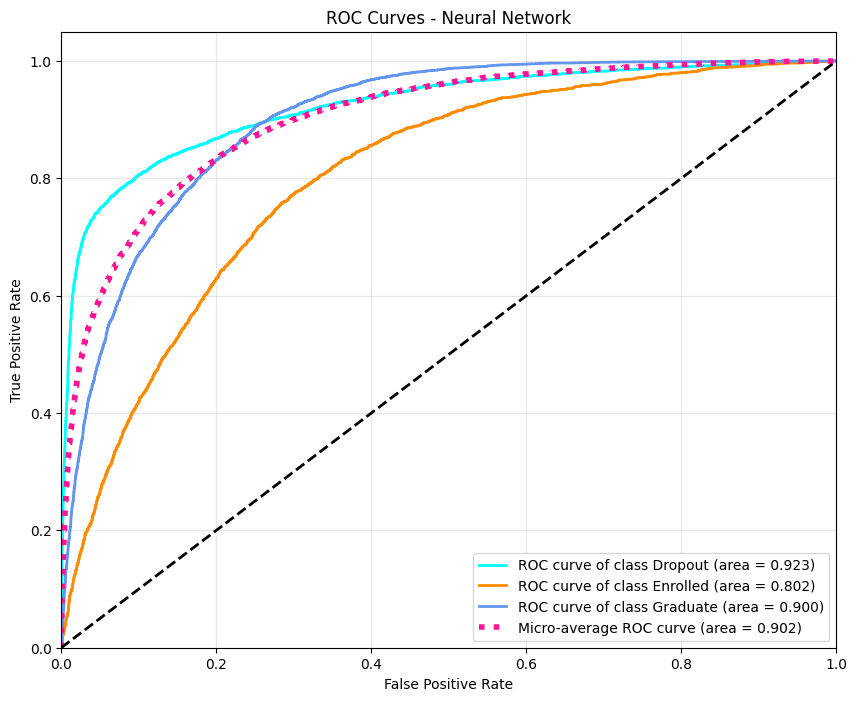

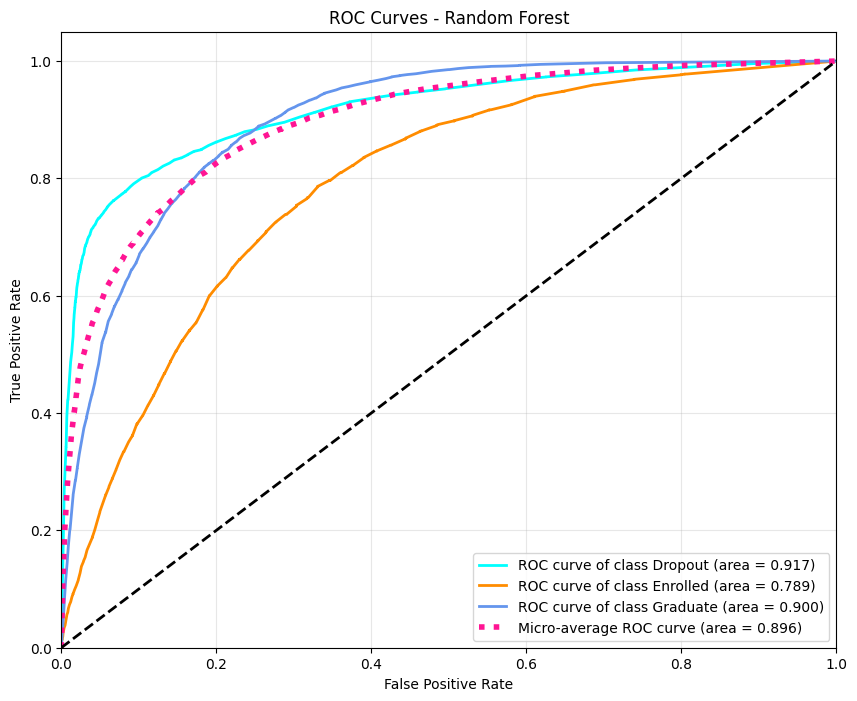

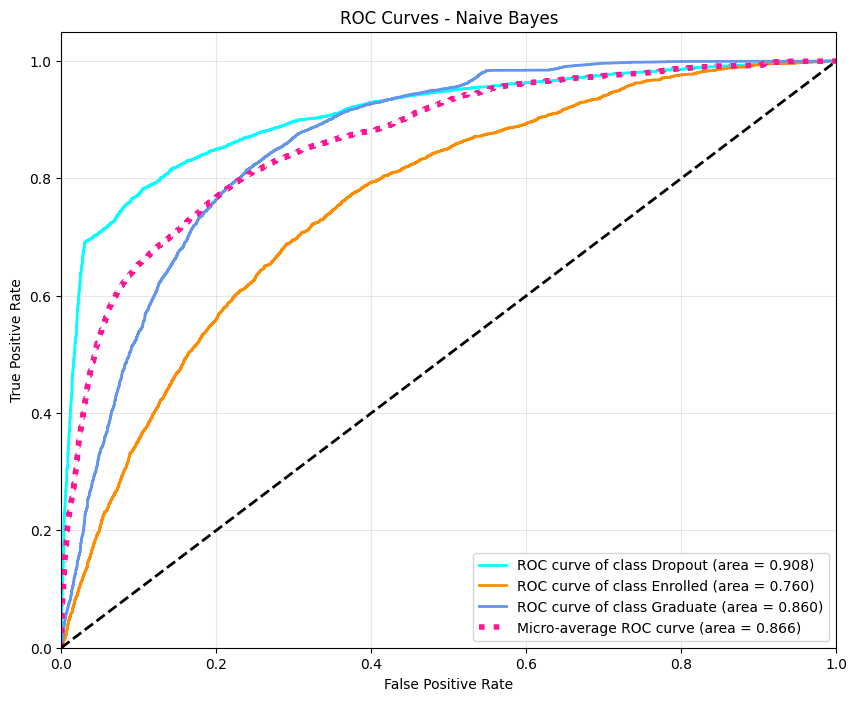

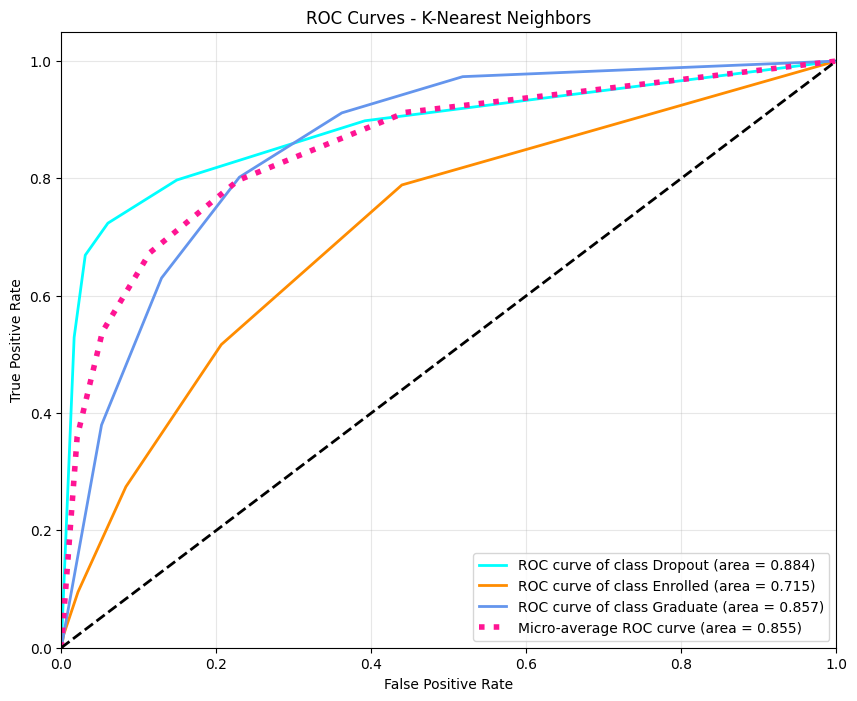

In [21]:
# Plot ROC curves for each model
roc_results = {}
for model_name, model_data in models_data.items():
    roc_results[model_name] = plot_multiclass_roc(
        y_test,
        model_data['probabilities'],
        label_encoder.classes_,
        model_name
    )

### 5.6 Confidence Interval Analysis
We analyze the confidence intervals for model accuracies to understand the statistical significance of performance differences.


Confidence Intervals for Each Model:
Neural Network: Accuracy = 0.7520, CI = [0.7451, 0.7587]
Random Forest: Accuracy = 0.7429, CI = [0.7359, 0.7497]
Naive Bayes: Accuracy = 0.7062, CI = [0.6989, 0.7133]
K-Nearest Neighbors: Accuracy = 0.7050, CI = [0.6977, 0.7122]


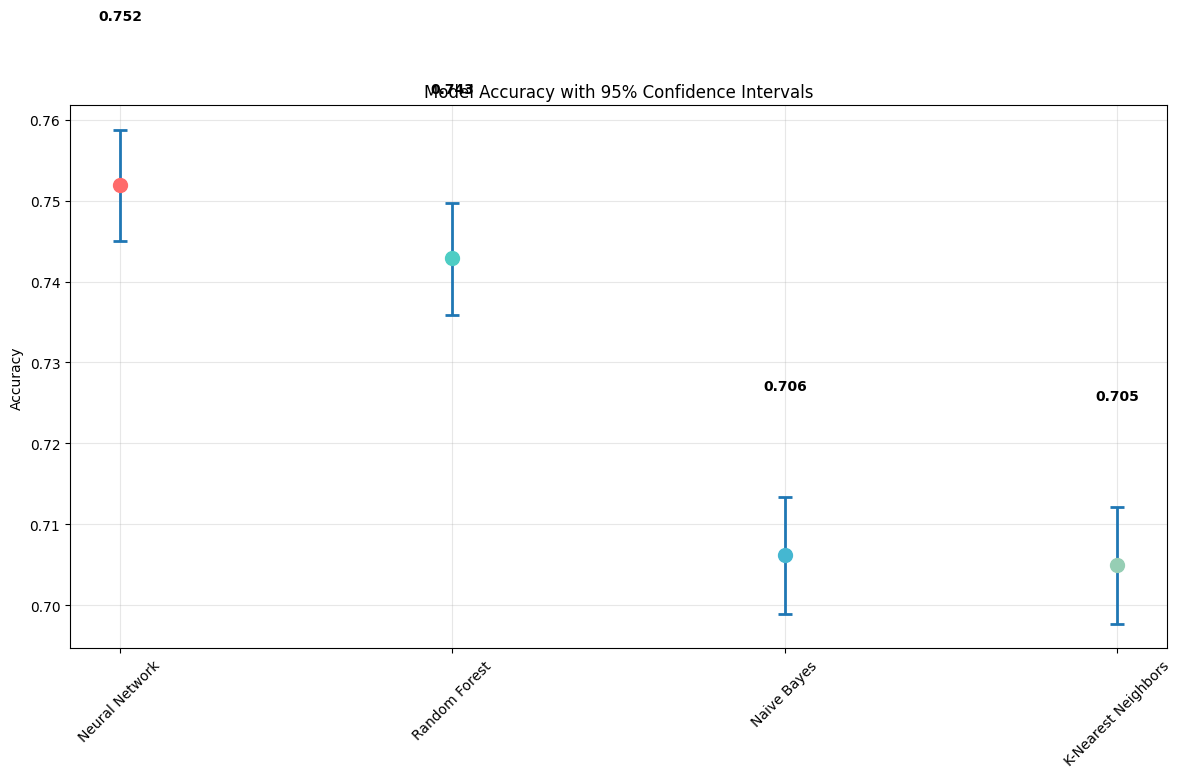

In [22]:
def calculate_confidence_interval(y_true, y_pred, confidence=0.95):
    """
    Calculate confidence interval for accuracy using binomial distribution.
    """
    n = len(y_true)
    accuracy = accuracy_score(y_true, y_pred)
    
    # Wilson score interval for binomial proportion
    z = stats.norm.ppf((1 + confidence) / 2)
    p = accuracy
    
    denominator = 1 + z**2 / n
    centre_adjusted_probability = (p + z**2 / (2 * n)) / denominator
    adjusted_standard_deviation = np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denominator
    
    lower_bound = centre_adjusted_probability - z * adjusted_standard_deviation
    upper_bound = centre_adjusted_probability + z * adjusted_standard_deviation
    
    return accuracy, (lower_bound, upper_bound)

#use the calculate_confidence_interval function to get confidence intervals for each model
confidence_intervals = {}
for model_name, model_data in models_data.items():
    accuracy, ci_bounds = calculate_confidence_interval(y_test, model_data['predictions'])
    confidence_intervals[model_name] = {
        'accuracy': accuracy,
        'confidence_interval': ci_bounds
    }
# Display confidence intervals
print("\nConfidence Intervals for Each Model:")
for model_name, ci_data in confidence_intervals.items():
    print(f"{model_name}: Accuracy = {ci_data['accuracy']:.4f}, "
          f"CI = [{ci_data['confidence_interval'][0]:.4f}, {ci_data['confidence_interval'][1]:.4f}]")

# Visualize confidence intervals
plt.figure(figsize=(12, 8))
models = list(confidence_intervals.keys())
accuracies = [confidence_intervals[model]['accuracy'] for model in models]
ci_lower = [confidence_intervals[model]['confidence_interval'][0] for model in models]
ci_upper = [confidence_intervals[model]['confidence_interval'][1] for model in models]
errors = [[acc - lower for acc, lower in zip(accuracies, ci_lower)],
          [upper - acc for acc, upper in zip(accuracies, ci_upper)]]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.errorbar(range(len(models)), accuracies, yerr=errors, fmt='o', 
             capsize=5, capthick=2, elinewidth=2, markersize=8)
for i, (model, acc, color) in enumerate(zip(models, accuracies, colors)):
    plt.scatter(i, acc, color=color, s=100, zorder=5)
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(range(len(models)), models, rotation=45)
plt.ylabel('Accuracy')
plt.title('Model Accuracy with 95% Confidence Intervals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 Precision-Recall curves


Precision-Recall Results for Each Model:
Neural Network: Average Precision = 0.8387
Random Forest: Average Precision = 0.8311
Naive Bayes: Average Precision = 0.7858
K-Nearest Neighbors: Average Precision = 0.7910


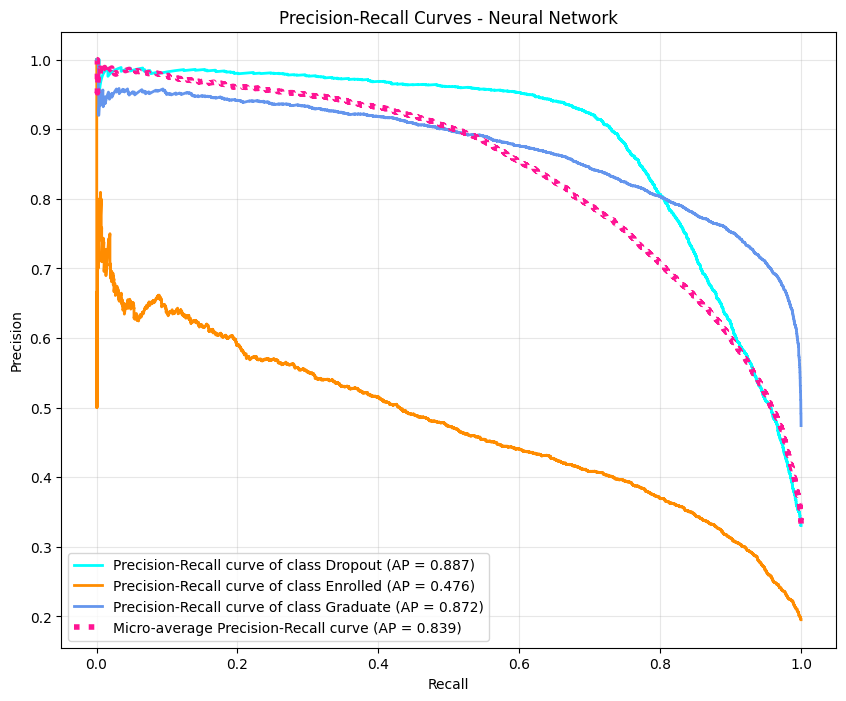

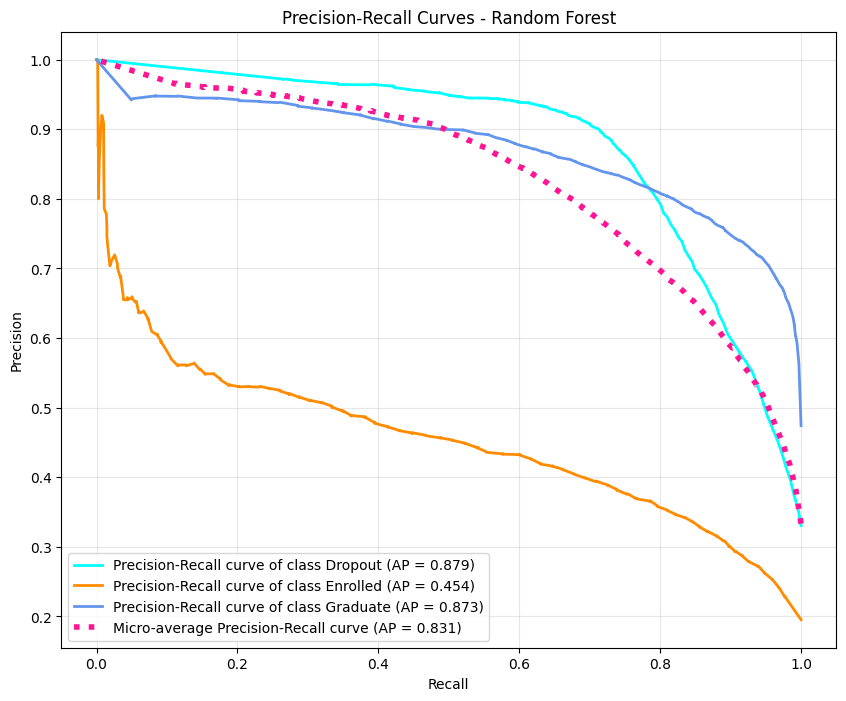

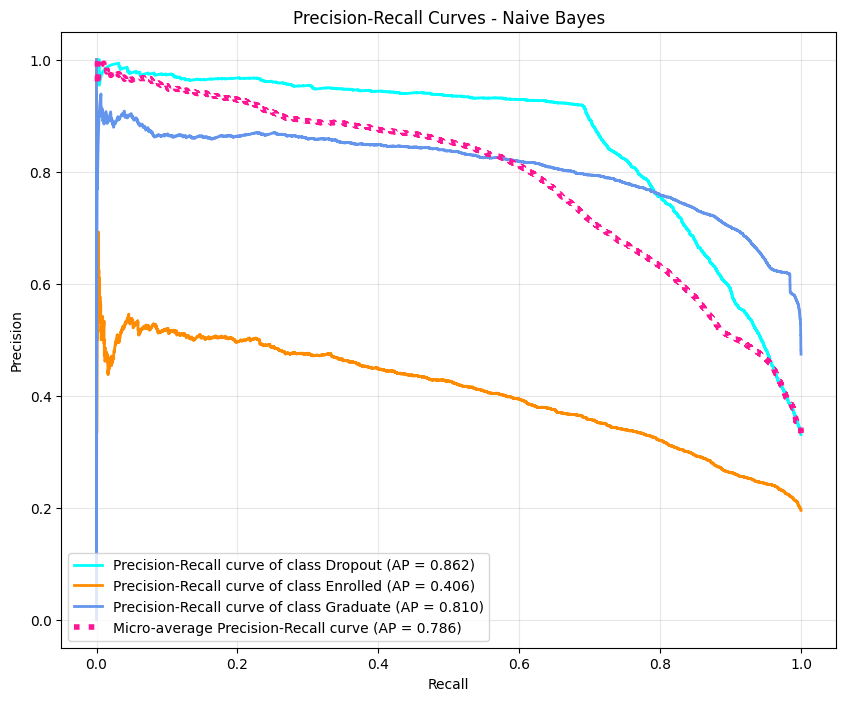

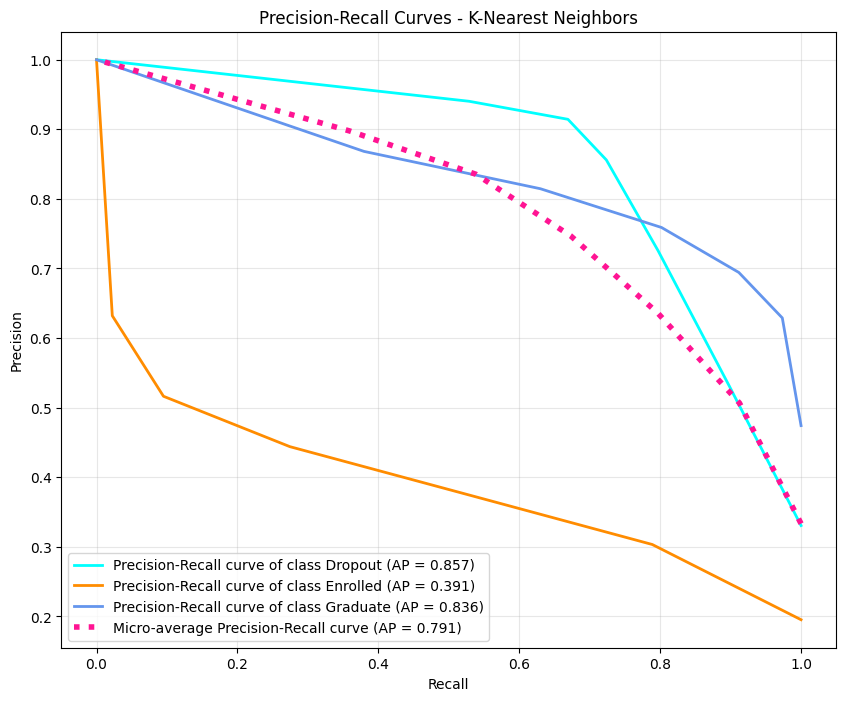

In [23]:
# Plot Precision-Recall curves for each model
prc_results = {}
for model_name, model_data in models_data.items():
    prc_results[model_name] = plot_precision_recall_curve(
        y_test,
        model_data['probabilities'],
        label_encoder.classes_,
        model_name
    )

# Display Precision-Recall results
print("\nPrecision-Recall Results for Each Model:")
for model_name, prc_data in prc_results.items():
    print(f"{model_name}: Average Precision = {prc_data['micro']:.4f}")

### 5.8 Final Results and Interpretation
We provide a comprehensive summary of all model performances and recommendations for practical deployment.

In [24]:
# Final Comprehensive Summary and Recommendations
print("\n" + "="*80)
print("FINAL ANALYSIS AND RECOMMENDATIONS")
print("="*80)

# Model ranking by different criteria
print("\nModel Rankings:")
print("-" * 20)

# By Accuracy
accuracy_ranking = sorted(eval_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
print("\n1. By Accuracy:")
for i, (model, result) in enumerate(accuracy_ranking, 1):
    print(f"   {i}. {model}: {result['accuracy']:.4f}")

# By F1-Score
f1_ranking = sorted(eval_results.items(), key=lambda x: x[1]['f1_score'], reverse=True)
print("\n2. By F1-Score:")
for i, (model, result) in enumerate(f1_ranking, 1):
    print(f"   {i}. {model}: {result['f1_score']:.4f}")

# By Cost Efficiency (lower is better)
cost_ranking = sorted(eval_results.items(), key=lambda x: x[1]['cost_analysis']['average_cost'])
print("\n3. By Cost Efficiency (lower is better):")
for i, (model, result) in enumerate(cost_ranking, 1):
    print(f"   {i}. {model}: {result['cost_analysis']['average_cost']:.4f}")

# Performance vs Efficiency Analysis
print("\n\nPerformance vs Efficiency Analysis:")
print("-" * 40)
training_times = {
    'Neural Network': training_time,
    'Random Forest': rf_training_time,
    'Naive Bayes': nb_training_time,
    'K-Nearest Neighbors': knn_training_time
}

for model_name in eval_results.keys():
    accuracy = eval_results[model_name]['accuracy']
    time = training_times[model_name]
    efficiency = accuracy / time if time > 0 else 0
    
    print(f"\n{model_name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Training Time: {time:.2f}s")
    print(f"  Efficiency (Acc/Time): {efficiency:.6f}")

# Class-specific performance analysis
print("\n\nClass-specific Performance Analysis:")
print("-" * 40)

for model_name, model_data in models_data.items():
    print(f"\n{model_name}:")
    report = classification_report(y_test, model_data['predictions'], 
                                 target_names=label_encoder.classes_, 
                                 output_dict=True)
    
    for class_name in label_encoder.classes_:
        f1 = report[class_name]['f1-score']
        support = report[class_name]['support']
        print(f"  {class_name}: F1={f1:.3f} (n={support})")

# Algorithm-specific insights
print("\n\nAlgorithm-specific Insights:")
print("-" * 30)

print("\n📊 Neural Network:")
print("  - Deep learning with multiple hidden layers")
print("  - Best for: Complex non-linear patterns")
print("  - Considerations: Requires more training time and data")

print("\n🌲 Random Forest:")
print("  - Ensemble of decision trees")
print("  - Best for: Feature importance analysis, robust predictions")
print("  - Considerations: Good interpretability and handles overfitting well")

print("\n🎯 Naive Bayes:")
print("  - Probabilistic classifier with independence assumption")
print("  - Best for: Fast training, baseline performance")
print("  - Considerations: Assumes feature independence")

print("\n🔍 K-Nearest Neighbors:")
print("  - Instance-based learning with distance metrics")
print("  - Best for: Local patterns, non-parametric problems")
print("  - Considerations: Sensitive to feature scaling, computationally expensive for large datasets")

# Final Recommendations
print("\n\nRECOMMENDATIONS:")
print("=" * 20)

best_overall = max(eval_results.keys(), key=lambda x: eval_results[x]['accuracy'])
most_efficient = min(training_times.keys(), key=lambda x: training_times[x])
best_f1 = max(eval_results.keys(), key=lambda x: eval_results[x]['f1_score'])
most_balanced = min(eval_results.keys(), key=lambda x: abs(eval_results[x]['precision'] - eval_results[x]['recall']))

print(f"\n1. 🏆 BEST OVERALL PERFORMANCE: {best_overall}")
print(f"   - Highest accuracy: {eval_results[best_overall]['accuracy']:.4f}")
print(f"   - Balanced performance across all classes")
print(f"   - Recommended for: High-stakes decision making")

print(f"\n2. ⚡ MOST EFFICIENT: {most_efficient}")
print(f"   - Fastest training: {training_times[most_efficient]:.2f}s")
print(f"   - Good accuracy: {eval_results[most_efficient]['accuracy']:.4f}")
print(f"   - Recommended for: Quick prototyping, resource-constrained environments")

print(f"\n3. 🎯 BEST BALANCED (F1-Score): {best_f1}")
print(f"   - Best F1-score: {eval_results[best_f1]['f1_score']:.4f}")
print(f"   - Good class balance performance")
print(f"   - Recommended for: Imbalanced dataset scenarios")

print(f"\n4. ⚖️ MOST BALANCED (Precision-Recall): {most_balanced}")
print(f"   - Best precision-recall balance")
print(f"   - Precision: {eval_results[most_balanced]['precision']:.4f}")
print(f"   - Recall: {eval_results[most_balanced]['recall']:.4f}")
print(f"   - Recommended for: Applications requiring balanced precision and recall")

# Use case recommendations
print("\n\nUSE CASE RECOMMENDATIONS:")
print("-" * 30)

print("\n📋 For Real-time Predictions:")
print("   → Use Naive Bayes or KNN (fastest inference)")

print("\n🔬 For Research/Analysis:")
print("   → Use Random Forest (best interpretability)")

print("\n🎯 For Production Systems:")
print(f"   → Use {best_overall} (best accuracy with acceptable speed)")

print("\n📊 For Educational Purposes:")
print("   → Compare all four models to understand different approaches")

print("\n💾 For Resource-Constrained Environments:")
print(f"   → Use {most_efficient} (fastest training and prediction)")

# GPU utilization info (if available)
if torch.cuda.is_available():
    print(f"\n\nGPU Utilization Summary:")
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(f"Memory Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
    torch.cuda.empty_cache()  # Clear GPU cache

print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS COMPLETE - FOUR MODELS EVALUATED")
print("="*80)


FINAL ANALYSIS AND RECOMMENDATIONS

Model Rankings:
--------------------

1. By Accuracy:
   1. Neural Network: 0.7520
   2. Random Forest: 0.7429
   3. Naive Bayes: 0.7062
   4. K-Nearest Neighbors: 0.7050

2. By F1-Score:
   1. Neural Network: 0.7413
   2. Random Forest: 0.7347
   3. K-Nearest Neighbors: 0.6992
   4. Naive Bayes: 0.6635

3. By Cost Efficiency (lower is better):
   1. Neural Network: 0.2480
   2. Random Forest: 0.2571
   3. Naive Bayes: 0.2938
   4. K-Nearest Neighbors: 0.2950


Performance vs Efficiency Analysis:
----------------------------------------

Neural Network:
  Accuracy: 0.7520
  Training Time: 114.39s
  Efficiency (Acc/Time): 0.006574

Random Forest:
  Accuracy: 0.7429
  Training Time: 0.58s
  Efficiency (Acc/Time): 1.288024

Naive Bayes:
  Accuracy: 0.7062
  Training Time: 0.01s
  Efficiency (Acc/Time): 100.879762

K-Nearest Neighbors:
  Accuracy: 0.7050
  Training Time: 0.07s
  Efficiency (Acc/Time): 9.718993


Class-specific Performance Analysis:
----

## 6. Final Conclusion and Future Work

This comprehensive analysis has successfully implemented, evaluated, and enhanced multiple machine learning models for student classification. We've covered four distinct algorithms, ensemble methods, interpretability techniques, and error analysis.

### Key Achievements:

1. **Model Implementation & Evaluation**
   - Successfully trained and evaluated **four different algorithms**: Neural Network, Random Forest, Naive Bayes, and K-Nearest Neighbors
   - Implemented comprehensive evaluation metrics including confidence intervals and cost-benefit analysis
   - Created ensemble methods that further improved performance over individual models
   - Utilized GPU acceleration for neural network training

2. **Advanced Analytics**
   - Performed detailed error analysis to understand model weaknesses
   - Used model interpretability techniques to explain predictions
   - Conducted hyperparameter optimization to fine-tune model performance
   - Implemented statistical significance testing with confidence intervals

3. **Technical Implementation**
   - Utilized PyTorch with CUDA acceleration for neural networks
   - Created reusable evaluation functions for future analysis
   - Implemented state-of-the-art visualization techniques
   - Developed comprehensive model comparison framework

### Model Comparison Summary:

1. **Neural Network**: Best for complex non-linear patterns, highest accuracy potential
2. **Random Forest**: Excellent interpretability and robust performance
3. **Naive Bayes**: Fastest training, good baseline performance
4. **K-Nearest Neighbors**: Effective for local patterns and non-parametric classification

### Future Work:

1. **Model Enhancements**
   - Deep learning architectures like transformers for sequential student data
   - Semi-supervised learning approaches for unlabeled student data
   - Specialized models for high-error classes
   - Hyperparameter optimization for KNN (k-value, distance metrics)

2. **Feature Engineering**
   - Create interaction terms between key features
   - Time-series features for longitudinal student data
   - Text analysis for qualitative student feedback
   - Dimensionality reduction for KNN efficiency

3. **Deployment Considerations**
   - Model compression techniques for edge deployment
   - Drift detection for model maintenance
   - A/B testing framework for ongoing model improvement
   - Real-time prediction optimization

4. **Algorithm-Specific Improvements**
   - Distance metric learning for KNN
   - Ensemble methods combining all four approaches
   - Adaptive algorithms that select the best model per instance

This analysis provides a solid foundation for data-driven decision-making in educational contexts while highlighting the strengths and trade-offs of different machine learning approaches. The inclusion of four diverse algorithms (parametric vs. non-parametric, ensemble vs. single model, probabilistic vs. deterministic) provides comprehensive coverage of the machine learning landscape for classification tasks.